Tasks:
1. add the equations leading to the approximation of the gradient
2. understand the encoding with the qstruct
3. The connection of the second plot to the equations below it.


# Simulation of the 2D Maxwell Equation using Quantum Hamiltonian Simulation

In the present notebook we simulate the **2D Maxwell equations** (TM mode) for an homogenous medium, employing a quantum Hamiltonian simulation. We work in **CGS** units, where the Maxwell equations take a symmetric form with a single wave speed parameter $c$. Earlier quantum approaches to Maxwell-type wave equations include explicit time-marching schemes [<a href="#ref-costa">1</a>] and variational/quantum-classical solvers [<a href="#ref-suau">2</a>]; here we instead block-encode the spatial operator and evolve it via Hamiltonian simulation.

The transverse-magnetic (TM) mode on a 2-D domain involves three field components — the out-of-plane electric field $E_z$ and the in-plane magnetic field components $H_x$, $H_y$ — governed by

$$
\frac{\partial E_z}{\partial t} = c\!\left(\frac{\partial H_y}{\partial x} - \frac{\partial H_x}{\partial y}\right), \qquad
\frac{\partial H_x}{\partial t} = -c\,\frac{\partial E_z}{\partial y}, \qquad
\frac{\partial H_y}{\partial t} = c\,\frac{\partial E_z}{\partial x}.
$$

Discretizing on a **Yee lattice** [<a href="#ref-yee">3</a>] with spacing $\Delta L$ and using backward ($\nabla^{b}$) and forward ($\nabla^{f}$) finite differences, the system can be written in matrix form as

$$
\frac{d}{dt}\begin{pmatrix} \vec{E}_z \\[4pt] \vec{H}_x \\[4pt] \vec{H}_y \end{pmatrix}
= \frac{c}{\Delta L}\,
\underbrace{\begin{pmatrix}
0 & -\nabla_y^{b} & \nabla_x^{b} \\
-\nabla_y^{f} & 0 & 0 \\
\nabla_x^{f} & 0 & 0
\end{pmatrix}}_{A}
\begin{pmatrix} \vec{E}_z \\[4pt] \vec{H}_x \\[4pt] \vec{H}_y \end{pmatrix}.
$$

The matrix $A$ is real and anti-symmetric ($A = -A^T$), which makes it anti-Hermitian. Therefore the time-evolution operator $e^{A\,c\,t / \Delta L}$ is unitary. This makes the system a natural fit for quantum Hamiltonian simulation, with $H=iA$.

We enforce **Perfect Electric Conductor (PEC)** boundary conditions on the exterior of the domain and on a rectangular obstacle inside it.

## Implementation with Classiq

We begin by importing the required Python

Importing latest version of Classiq:

In [1]:
!pip install -qq "classiq[qsp]" -U

We import the several utility functions from the adjacent `maxwell_utils.py`.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from maxwell_utils import (
    build_initial_state_vector,
    build_maxwell_evolution_matrix,
    classical_maxwell_simulation,
    dataframe_to_state_vector,
    fidelity,
    fields_max_abs,
    get_block_encoding,
    normalize_phase,
    plot_fields,
    plot_fields_from_dataframe,
    plot_geometry,
    plot_matrix,
    plot_yee_lattice,
    run_simulation,
    vaildate_block_encoding,
)

from classiq import *

## Problem Definition

We discretize the domain on an $L_x \times L_y$ **Yee lattice**. In this staggered grid the electric field $E_z$ lives at the **vertices** (integer grid points), while the magnetic components $H_x$ and $H_y$ are located at the **edge midpoints**:

- $E_z(i,\,j)$ — grid vertices.
- $H_x(i,\,j+\tfrac{1}{2})$ — midpoints of vertical edges (between consecutive $y$-nodes at fixed $x$).
- $H_y(i+\tfrac{1}{2},\,j)$ — midpoints of horizontal edges (between consecutive $x$-nodes at fixed $y$).


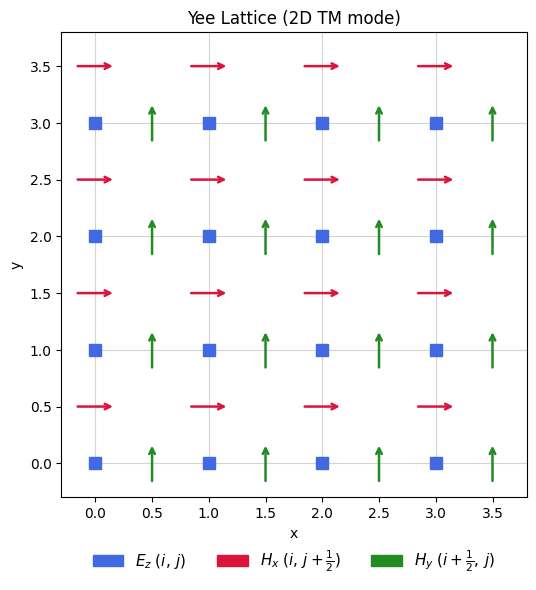

In [3]:
plot_yee_lattice()

We next define the problem parameters, defining the grid, timescale and geometry of the system and define a Gaussian initial state.

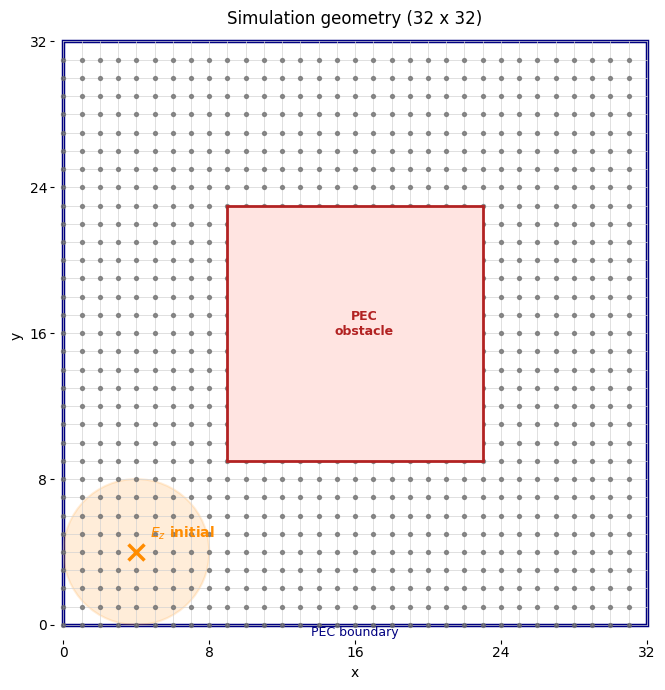

In [4]:
N_x = 5
N_y = 5
T = 5
c = 1

# grid
L_x = 2**N_x
L_y = 2**N_y

dL = 1 / min(L_x, L_y)

# initial state - gaussian parameters
sigma_x = 1 / (8 * dL)
sigma_y = 1 / (8 * dL)
mu_x = (L_x) / 8
mu_y = (L_y) / 8

# geometry - rectangle
middle_x = 0.5
middle_y = 0.5
side_length = 0.5

half_length = side_length / 2
top_x = 1 + int(np.floor((middle_x + half_length) * (L_x - 2))) + 1
top_y = 1 + int(np.floor((middle_y + half_length) * (L_y - 2))) + 1
bottom_x = 1 + int(np.ceil((middle_x - half_length) * (L_x - 2)))
bottom_y = 1 + int(np.ceil((middle_y - half_length) * (L_y - 2)))

plot_geometry(L_x, L_y, bottom_x, top_x, bottom_y, top_y, mu_x, mu_y, sigma_x, sigma_y)

### Quantum Encoding of the Electromagnetic System

We introduce a QStruct to represent the EM field, utilizing two `QNum`s to encode the position (one for the $x$-coordinate and one for $y$), in addition two additional qubits encode the vector `[Ez, unused, Hx, Hy]` for each coordinate.???????/

In [5]:
class EMState(QStruct):
    x: QNum[N_x]
    y: QNum[N_y]
    direction: QBit  # Hx=0, Hy=1
    field: QBit  # E=0, H=1

### Construction of the Quantum Functions 

#### Gradients

We start by defining the **1D periodic backward and forward gradient** operators on a grid of size $N$. These are $N \times N$ circulant matrices:

$$
\nabla^{b} = I - S^{+1} = \begin{pmatrix}
1 & 0 & \cdots & 0 & -1 \\
-1 & 1 & 0 & \cdots & 0 \\
0 & -1 & 1 & \ddots & \vdots \\
\vdots & \ddots & \ddots & \ddots & 0 \\
0 & \cdots & 0 & -1 & 1
\end{pmatrix}, \qquad
\nabla^{f} = S^{-1} - I = \begin{pmatrix}
-1 & 1 & 0 & \cdots & 0 \\
0 & -1 & 1 & \ddots & \vdots \\
\vdots & \ddots & \ddots & \ddots & 0 \\
0 & \cdots & 0 & -1 & 1 \\
1 & 0 & \cdots & 0 & -1
\end{pmatrix},
$$

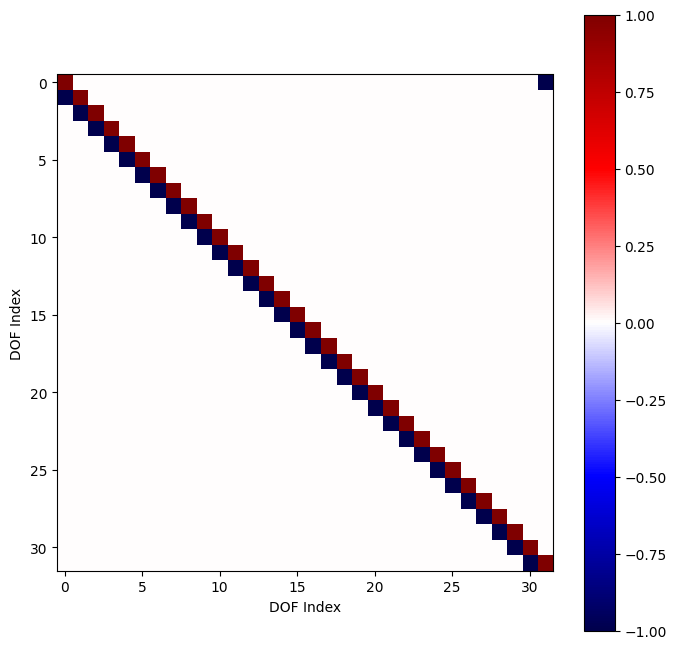

In [6]:
from classiq.qmod.symbolic import exp, pi


@qfunc
def grad_backwards_periodic(r: QNum, block: QBit):
    """
    +1 on the diagonal
    -1 below the diagonal
    """
    lcu(
        coefficients=[0.5, -0.5],
        unitaries=[lambda: None, lambda: inplace_add(1, r)],
        block=block,
    )


@qfunc
def grad_forwards_periodic(r: QNum, block: QBit):
    """
    +1 above the diagonal
    -1 below the diagonal
    """
    invert(grad_backwards_periodic)(r, block)
    phase(pi)


SIZE = L_x
grad_back_ref = np.eye(SIZE) - np.roll(np.eye(SIZE), 1, 0)
grad_back_scale = 2
plot_matrix(grad_back_ref)
# vaildate_block_encoding(grad_backwards_periodic, 1, grad_back_ref, expected_scale=grad_back_scale)

We next assemble the full gradient from the backward and forward gradients.

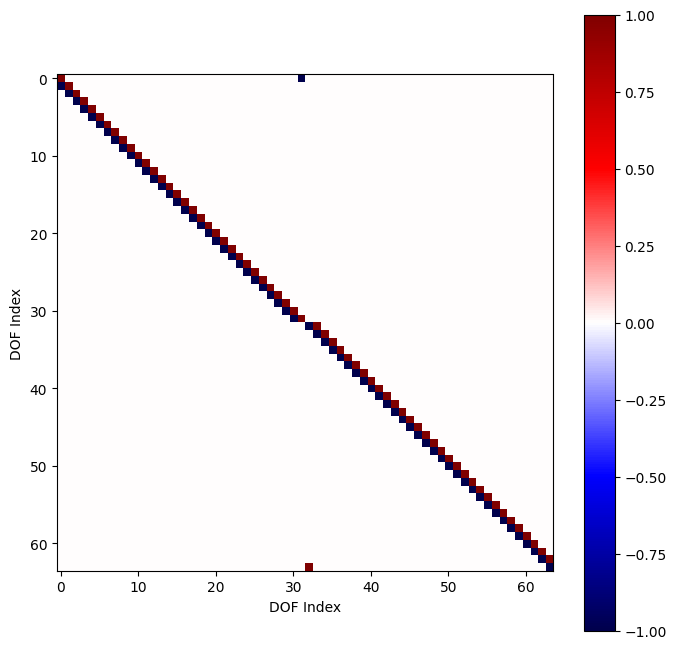

Fidelity: 1.000000
Encoding Scaling: 2.000000 Expected: 2.000000


In [ ]:
@qfunc
def grad_backwards_forwards_periodic(r: QNum, toggle: QBit, block: QBit) -> None:
    """
    2 blocks (based on the toggle qubit)
    upper left - backwards
    lower right - forwards
    """
    control(
        toggle,
        lambda: grad_forwards_periodic(r, block),  # toggle=1
        lambda: grad_backwards_periodic(r, block),  # toggle=0
    )


grad_back_ref = np.eye(L_x) - np.roll(np.eye(L_x), 1, 0)
grad_forward_ref = np.roll(np.eye(L_x), -1, 0) - np.eye(L_x)
grad_b_f_ref = np.block(
    [[grad_back_ref, np.zeros((L_x, L_x))], [np.zeros((L_x, L_x)), grad_forward_ref]]
)

grad_b_f_scale = 2
plot_matrix(grad_b_f_ref)


#@qfunc
#def grad_b_f_wrapper(state: QArray, block: QBit):
#    grad_backwards_forwards_periodic(
#        state[: state.len - 1], state[state.len - 1], block
#    )


#vaildate_block_encoding(
#    grad_b_f_wrapper, 1, grad_b_f_ref, expected_scale=grad_b_f_scale
#)

### Assemble the Electromagnetic Derivatives 

We build the full matrix as a decomposition of matrices:
$$
A_{E_z,H_x} =
\begin{pmatrix}
0 & 0 & -\nabla_y^{b} & 0 \\
0 & 0 & 0 & 0 \\
-\nabla_y^{f} & 0 & 0 & 0 \\
0 & 0 & 0 & 0
\end{pmatrix}
\quad
\begin{matrix} \leftarrow E_z \\ \leftarrow \text{(unused)} \\ \leftarrow H_x \\ \leftarrow H_y \end{matrix}
$$

and:
$$
A_{E_z,H_y} =
\begin{pmatrix}
0 & 0 & 0 & \nabla_x^{b} \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
\nabla_x^{f} & 0 & 0 & 0
\end{pmatrix}
\quad
\begin{matrix} \leftarrow E_z \\ \leftarrow \text{(unused)} \\ \leftarrow H_x \\ \leftarrow H_y \end{matrix}
$$

The full periodic Maxwell operator is assembled as an **LCU** of the two interactions:

$$
A = A_{E_z,H_x} + A_{E_z,H_y} =
\begin{pmatrix}
0 & 0 & -\nabla_y^{b} & \nabla_x^{b} \\
0 & 0 & 0 & 0 \\
-\nabla_y^{f} & 0 & 0 & 0 \\
\nabla_x^{f} & 0 & 0 & 0
\end{pmatrix}
\quad
$$

In [9]:
@qfunc
def ez_hx_interaction(em_state: EMState, block: QArray) -> None:
    """
    dt(Ez) += -dy(Hx)
    dt(Hx) += -dy(Ez)
    """
    # swap columns
    em_state.field ^= 1

    # block encode
    grad_backwards_forwards_periodic(em_state.y, em_state.field, block[1:])

    # apply the minus sign to the components
    phase(pi)

    # delete rows 1, 3 (in this case could delete instead the columns, by doing that before the block encoding)
    block[0] ^= em_state.direction


@qfunc
def ez_hy_interaction(em_state: EMState, block: QArray) -> None:
    """
    dt(Ez) += dx(Hy)
    dt(Hy) += dx(Ez)
    """
    # swap columns 0, 3 by doing the following 2 swaps:
    # swap columns 0, 1 and 2, 3
    em_state.direction ^= 1
    # swap columns 0, 2 and 1, 3
    em_state.field ^= 1

    # block encode
    grad_backwards_forwards_periodic(em_state.x, em_state.field, block[1:])

    # delete rows 1, 2
    block[0] ^= em_state.direction ^ em_state.field


@qfunc
def periodic_maxwell_operator(em_state: EMState, block: QArray) -> None:
    """
    Assemble the full periodic evolution operator, without the boundary conditions
    """
    lcu(
        coefficients=[0.5, 0.5],
        unitaries=[
            lambda: ez_hx_interaction(em_state, block[1:]),
            lambda: ez_hy_interaction(em_state, block[1:]),
        ],
        block=block[0],
    )

Validate the block encodings:

In [10]:
LL = L_x * L_y
id_Lx, id_Ly = np.eye(L_x), np.eye(L_y)
zero_LL = np.zeros((LL, LL))

_grad_b_y = id_Ly - np.roll(id_Ly, 1, 0)
_grad_f_y = np.roll(id_Ly, -1, 0) - id_Ly
_grad_b_x = id_Lx - np.roll(id_Lx, 1, 0)
_grad_f_x = np.roll(id_Lx, -1, 0) - id_Lx
grad_b_y = np.tensordot(_grad_b_y, id_Lx, axes=0).transpose(0, 2, 1, 3).reshape(LL, LL)
grad_f_y = np.tensordot(_grad_f_y, id_Lx, axes=0).transpose(0, 2, 1, 3).reshape(LL, LL)
grad_b_x = np.tensordot(id_Ly, _grad_b_x, axes=0).transpose(0, 2, 1, 3).reshape(LL, LL)
grad_f_x = np.tensordot(id_Ly, _grad_f_x, axes=0).transpose(0, 2, 1, 3).reshape(LL, LL)

ez_hx_ref = np.block(
    [
        [zero_LL, zero_LL, -grad_b_y, zero_LL],
        [zero_LL, zero_LL, zero_LL, zero_LL],
        [-grad_f_y, zero_LL, zero_LL, zero_LL],
        [zero_LL, zero_LL, zero_LL, zero_LL],
    ]
)

ez_hy_ref = np.block(
    [
        [zero_LL, zero_LL, zero_LL, grad_b_x],
        [zero_LL, zero_LL, zero_LL, zero_LL],
        [zero_LL, zero_LL, zero_LL, zero_LL],
        [grad_f_x, zero_LL, zero_LL, zero_LL],
    ]
)
scale = 2

# Ez-Hx
# ez_hx_mat = get_block_encoding(ez_hx_interaction, N_x + N_y + 2, 2)
# plot_matrix(ez_hx_mat * scale, "$A_{E_z, H_x}$ (block encoding)")
vaildate_block_encoding(ez_hx_interaction, 2, ez_hx_ref, expected_scale=scale)

# Ez-Hy
# ez_hy_mat = get_block_encoding(ez_hy_interaction, N_x + N_y + 2, 2)
# plot_matrix(ez_hy_mat * scale, "$A_{E_z, H_y}$ (block encoding)")
vaildate_block_encoding(ez_hy_interaction, 2, ez_hy_ref, expected_scale=scale)

For the boundary conditions we delete cells in the matrix $A$ using flag qubits.
We enforce the boundary conditions on the $E_z$ component. For the boundary we check for the origins of each axis, and the other edge will be set implicitly by the periodicity of the operator.

In [11]:
@qperm
def rectangle_boundary_conditions(x: Const[QNum], y: Const[QNum], flag: QBit) -> None:
    """
    flip flag (a block qubit) inside a rectangle
    """
    assert (
        (top_x > bottom_x and top_y > bottom_y)
        and (top_x < L_x and top_y < L_y)
        and (bottom_x > 0 and bottom_y > 0)
    ), "Illegal rectangle"

    # can use xor in each axis as the conditions are mutually exclusive
    flag ^= (~((x >= top_x) ^ (x < bottom_x))) & (~((y >= top_y) ^ (y < bottom_y)))


@qperm
def exterior_boundary_conditions(x: Const[QNum], y: Const[QNum], flag: QBit) -> None:
    """
    flip flag (a block qubit) at the boundary of the grid.
    In this case we only enforce the origin of each axis.
    """
    # naively we would do (y == 0) & (x==0), which will allocate an auxilliary qubit
    # We can do xor because (0, 0) is decoupled from the rest of the system
    flag ^= (y == 0) ^ (x == 0)


@qperm
def pec_boundary_conditions(em_state: Const[EMState], flag: QBit) -> None:
    """
    Enforce full boundary conditions. We apply them only on Ez, and they will apply
    implicitly on the Hx, Hy components.
    """
    # apply the boundary only on Ez
    control(
        (em_state.direction == 0) & (em_state.field == 0),
        # can use xor in as the conditions are mutually exclusive
        lambda: (
            exterior_boundary_conditions(em_state.x, em_state.y, flag),
            rectangle_boundary_conditions(em_state.x, em_state.y, flag),
        ),
    )


@qfunc
def maxwell_operator(em_state: EMState, block: QArray) -> None:
    """
    Full Maxwell evolution operator, including the boundary conditions.
    """
    within_apply(
        # We delete columns and not just rows (equations), to keep the anti-symmetry of the evolution
        # matrix. It is possible to use the same flag qubit, because the diagonal of periodic_maxwell_operator
        # is all zeros, thus we save 1 block qubit.
        within=lambda: pec_boundary_conditions(em_state, block[0]),
        apply=lambda: periodic_maxwell_operator(em_state, block[1:]),
    )

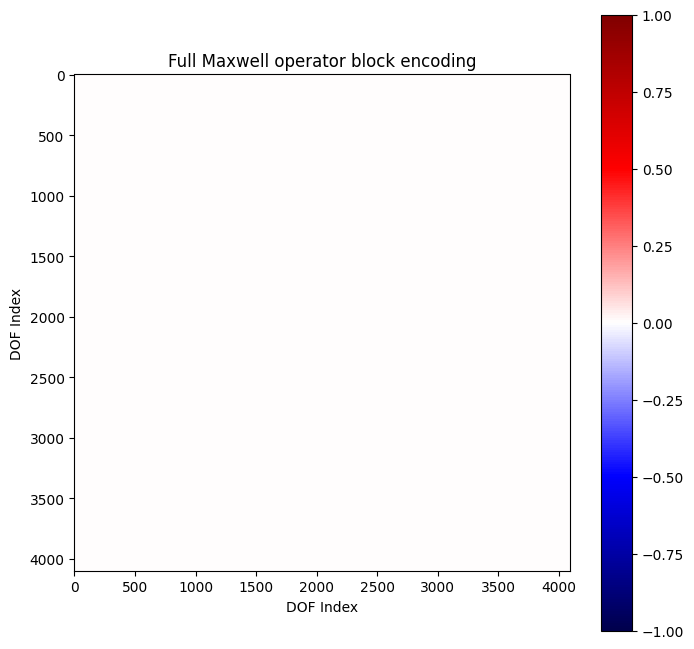

In [12]:
if N_x + N_y <= 4:
    # To be able to simulate the matrix, we need small number of qubits
    maxwell_mat = get_block_encoding(maxwell_operator, EMState.num_qubits, 4)
else:
    # otherwise, calculate it numerically
    maxwell_mat = build_maxwell_evolution_matrix(
        L_x, L_y, bottom_x, top_x, bottom_y, top_y
    )

plot_matrix(maxwell_mat, "Full Maxwell operator block encoding")

## Evolve the Maxwell operator using Hamiltonian Simulation with GQSP

Our goal is to implement the time-evolution operator $e^{(c/\Delta L)\,A\,t}$, where $A$ is the anti-symmetric Maxwell matrix. We achieve this through **Generalized Quantum Signal Processing (GQSP)** [<a href="#ref-gqsp">2</a>] in three steps.

### 1. From block encoding to walk operator

Suppose $U_A$ is a block encoding of $A/\alpha$ (with $\alpha$ the encoding scale). Since $A$ is anti-symmetric, $H = iA$ is **Hermitian**, so multiplying the block encoding by a global phase of $i$ gives a block encoding of the Hermitian matrix $H/\alpha$. The **walk operator** is then

$$
W = R \cdot (i\,U_A), \qquad R = 2\,|0\rangle\!\langle 0|_{\text{block}}-I,
$$

where $R$ is the reflection about the block-encoding subspace. If $\lambda_k$ are the eigenvalues of $H/\alpha$ (real, with $|\lambda_k| \le 1$), then the walk operator has eigenvalues $e^{\pm i\,\theta_k}$ with $\theta_k = \arccos(\lambda_k)$.

### 2. Jacobi–Anger polynomial approximation

The desired evolution in the eigenbasis is $e^{-i H t} = e^{A t}$. In terms of the walk operator eigenphases:

$$
e^{-i\,\alpha\,t_{\text{eff}}\,\cos\theta}
\quad\text{with}\quad
t_{\text{eff}} = \frac{c\,t}{\Delta L},
$$

where $\alpha\,t_{\text{eff}}$ is the effective evolution parameter. This function is approximated by a truncated **Jacobi–Anger expansion** — a Laurent polynomial in $e^{i\theta}$:

$$
e^{-i\,\alpha\,t_{\text{eff}}\,\cos\theta} \;\approx\; \sum_{d=-D}^{D} c_d \, e^{i\,d\,\theta},
$$

where $D$ (the GQSP degree) is chosen to achieve a target precision $\varepsilon$.
Specifically we approximate a scaled version of the function, to gurantee gqsp phase finding stability.

In [13]:
from classiq.applications.qsp import (
    gqsp_phases,
    poly_jacobi_anger_degree,
    poly_jacobi_anger_exp_cos,
)


@qfunc
def walk_operator(em_state: EMState, block: QArray) -> None:
    # block encode the anti-symmetric evolution operator
    maxwell_operator(em_state, block)

    # apply an i phase to turn the maxwell operator to a Hamiltonian
    phase(pi / 2)

    # reflect about the subspace of the block-encoding
    reflect_about_zero(block)


encoding_scale = 4.0  # pay a factor of 2 for each lcu.


# scale the gqsp polynomial to be below 1 to improve numerical stability
GQSP_SCALE = 0.5
GQSP_EPS = 1e-6


@qfunc
def hamiltonan_simulation(em_state: EMState, block: QArray, t: float):  # evolution time
    effective_time = t * encoding_scale * (c / dL)

    # use the gqsp to turn the walk operator with eigenvalues exp(i*arccos(lambda))
    # to exp(-i*lambda*t).
    gqsp_degree = poly_jacobi_anger_degree(GQSP_EPS, effective_time)
    print(f"GQSP degree: {gqsp_degree}")

    # approximate exp(i*cos(x)*t) by a polynomial sum_d{c_d exp(i*x*d)}
    poly = GQSP_SCALE * poly_jacobi_anger_exp_cos(gqsp_degree, -effective_time)
    negative_power = (len(poly) - 1) // 2  # use a both negative and positive exponents

    # compute the phases for the wanted polynomial
    phases = gqsp_phases(poly)

    gqsp(
        u=lambda: walk_operator(em_state, block[1:]),
        aux=block[0],
        phases=phases,
        negative_power=negative_power,
    )

# Preparing the initial state

In [14]:
def maxwell_2d_initial_state(x: float, y: float, direction: int, field: int) -> float:
    """
    Load a 2d gaussian state, taking into account the boundary conditions.
    """
    # only Ez (electric field) is nonzero initially
    if direction != 0 or field != 0:
        return 0.0
    # no field on the boundaries
    if x == 0 or y == 0:
        return 0.0
    # no field in the rectangle
    if bottom_x <= x < top_x and bottom_y <= y < top_y:
        return 0.0
    # field in the rest of the grid
    return float(
        np.exp(
            -((x - mu_x) ** 2) / (2 * sigma_x**2) - ((y - mu_y) ** 2) / (2 * sigma_y**2)
        )
    )


@qfunc
def prepare_initial_state(em_state: Output[EMState]) -> None:
    """
    Prepare the initial state of the electromagnetic field. Load a 2d gaussian state, taking into account
    the boundary conditions.
    """
    init_amplitudes = lookup_table(
        maxwell_2d_initial_state,
        [em_state.x, em_state.y, em_state.direction, em_state.field],
    )
    plot_fields(init_amplitudes, L_x, L_y, "initial state t=0")
    prepare_amplitudes(init_amplitudes, 0, em_state)

## Run the Full Algorithm

In [15]:
BLOCK_SIZE = 5


@qfunc
def main(em_state: Output[EMState], block: Output[QNum[BLOCK_SIZE]]) -> None:
    allocate(block)

    prepare_initial_state(em_state)
    hamiltonan_simulation(em_state, block, T)

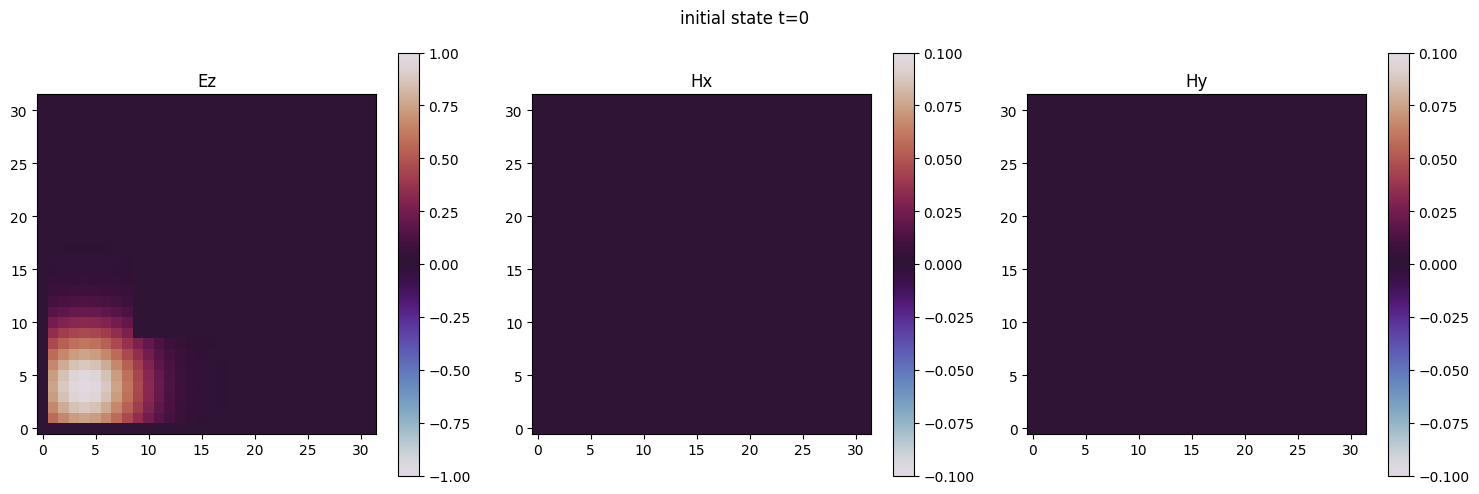

GQSP degree: 686
Synthesizing...
Quantum program link: https://platform.classiq.io/circuit/3AX5rd3ADYAMUpd4acm1fV3Knqk
Synthesis completed.
Starting execution...
Execution completed.


In [16]:
df, qprog = run_simulation(main, show=True)

In [17]:
df.head()

,em_state.x,em_state.y,em_state.direction,em_state.field,block,amplitude,magnitude,phase,probability,bitstring
0,25,25,0,0,0,-0.010992-0.036236j,0.04,-0.59π,0.001434,00000110011100100000
1,25,26,0,0,0,-0.010133-0.033403j,0.03,-0.59π,0.001218,00000110101100100000
2,26,25,0,0,0,-0.010133-0.033403j,0.03,-0.59π,0.001218,00000110011101000000
3,24,26,0,0,0,-0.009153-0.030172j,0.03,-0.59π,0.000994,00000110101100000000
4,26,24,0,0,0,-0.009153-0.030172j,0.03,-0.59π,0.000994,00000110001101000000


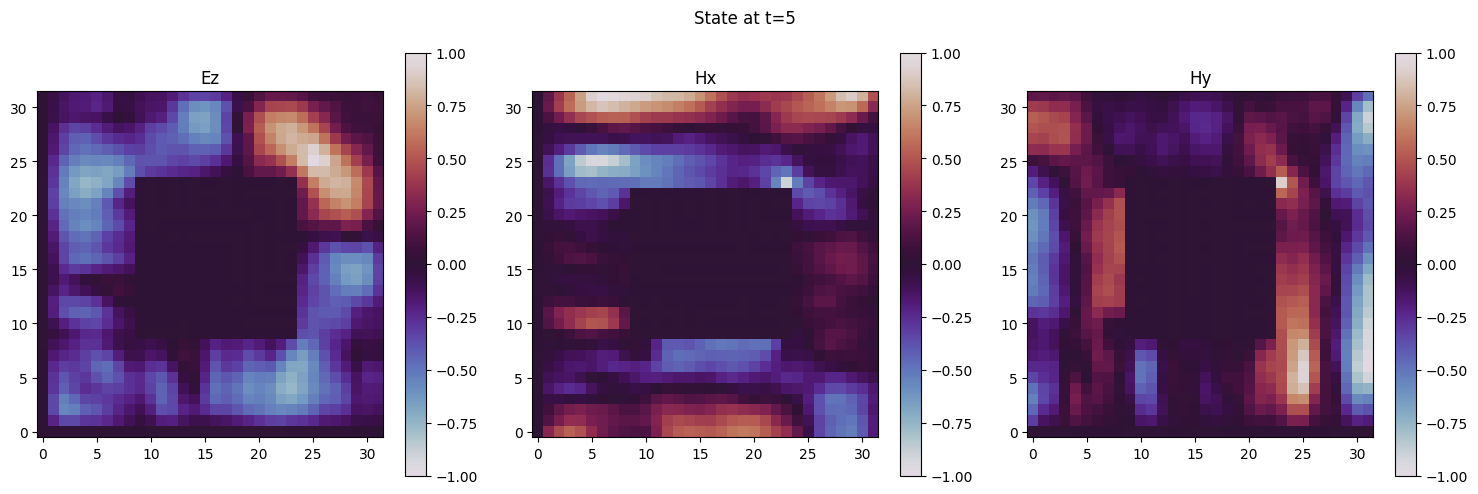

In [18]:
plot_fields_from_dataframe(df, f"State at t={T}")

## Classical Validation

Compare the quantum simulation results against a classical reference computed via matrix exponentiation.

Fidelity (quantum vs classical): 1.000000
Encoding Scaling: 0.500000 Expected: 0.500000


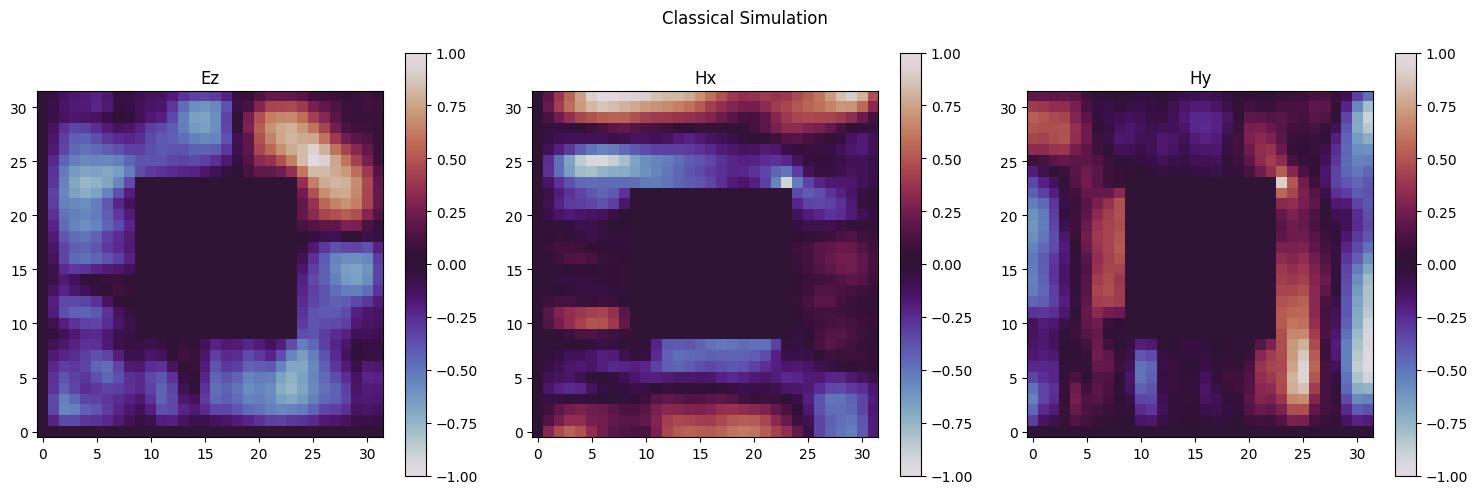

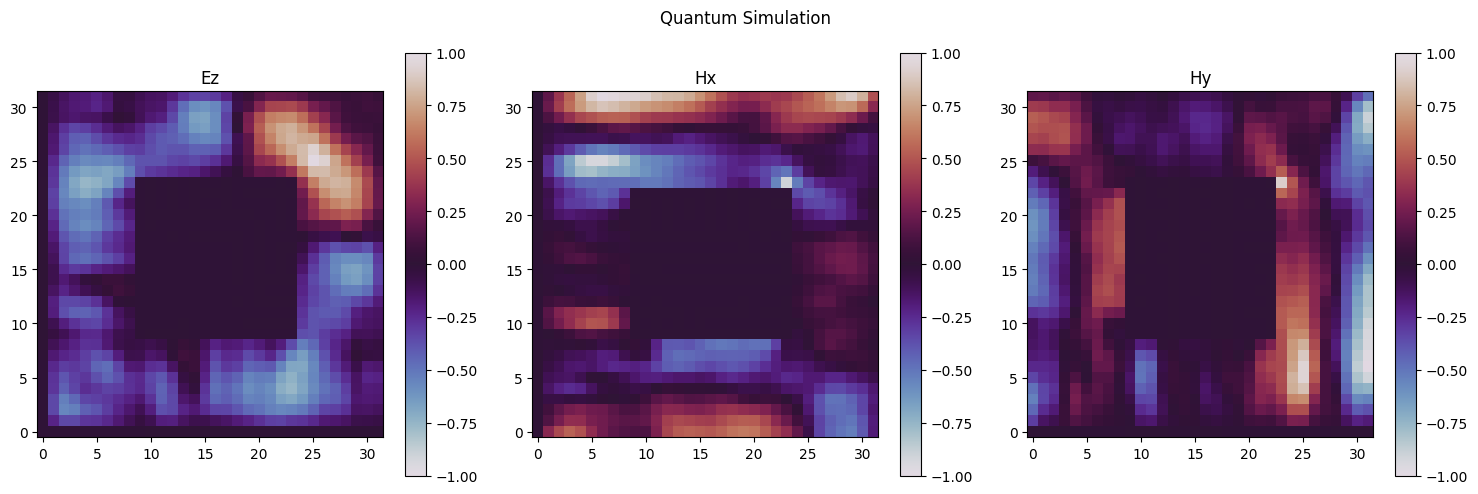

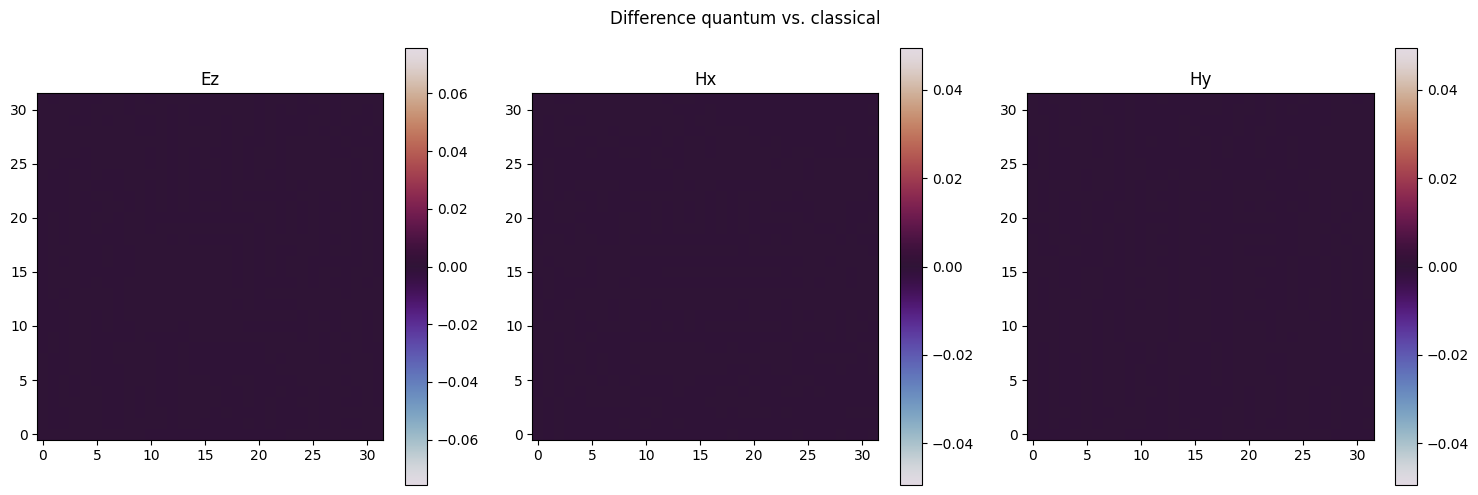

In [19]:
# Run the classical simulation
coeff = c * T / dL
classical_vec = classical_maxwell_simulation(
    L_x,
    L_y,
    coeff,
    maxwell_2d_initial_state,
    bottom_x,
    top_x,
    bottom_y,
    top_y,
)
classical_vec = normalize_phase(classical_vec)

# Compute fidelity
quantum_vec, _, _ = dataframe_to_state_vector(df)
quantum_vec = normalize_phase(quantum_vec)

fid = fidelity(quantum_vec / GQSP_SCALE, classical_vec)
print(f"Fidelity (quantum vs classical): {fid:.6f}")
print(
    f"Encoding Scaling: {np.linalg.norm(quantum_vec)/np.linalg.norm(classical_vec):.6f}",
    f"Expected: {GQSP_SCALE:.6f}",
)

# Plot both results
plot_fields(classical_vec, L_x, L_y, title="Classical Simulation")
plot_fields(quantum_vec, L_x, L_y, title="Quantum Simulation")

# Difference plot, normalized to the classical reference scale
ref_max = fields_max_abs(classical_vec, L_x, L_y)
diff_vec = quantum_vec / GQSP_SCALE - classical_vec
plot_fields(
    diff_vec, L_x, L_y, title="Difference quantum vs. classical", field_vmax=ref_max
)

## References

<a id='ref-costa'>[1]</a>: [Costa, P. C. S., Jordan, S., and Ostrander, A. *Quantum algorithm for simulating the wave equation.* Physical Review A **99**, 012323 (2019).](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.99.012323)

<a id='ref-suau'>[2]</a>: [Suau, A., Staffelbach, G., and Calandra, H. *Practical quantum computing: solving the wave equation using a quantum approach.* ACM Transactions on Quantum Computing **2**, 1–35 (2021).](https://dl.acm.org/doi/10.1145/3430030)

<a id='ref-yee'>[3]</a>: [Yee, K. *Numerical solution of initial boundary value problems involving Maxwell's equations in isotropic media.* IEEE Transactions on Antennas and Propagation **14**, 302–307 (1966).](https://ieeexplore.ieee.org/document/1138693)

<a id='ref-gqsp'>[4]</a>: [Motlagh, D., and Wiebe, N. *Generalized quantum signal processing.* PRX Quantum **5**, 020368 (2024).](https://journals.aps.org/prxquantum/abstract/10.1103/PRXQuantum.5.020368)